## crptocurrency Liquidity model

* nderstand the pattern 
* data cleaning
* Exploratory data analysis
* Data Pre-Processing
* Model Training 
* Choose best model

In [1]:
# import all important library

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the data 

df1 = pd.read_csv('coin_gecko_2022-03-16.csv')
df2 = pd.read_csv('coin_gecko_2022-03-17.csv')

In [3]:
df1.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16


In [4]:
df2.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40851.380000,0.001,0.000,-0.027,2.047612e+10,7.760774e+11,2022-03-17
1,Ethereum,ETH,2824.420000,0.004,0.029,0.034,1.364041e+10,3.390772e+11,2022-03-17
2,Tether,USDT,1.000000,-0.000,0.000,0.000,4.413140e+10,8.020588e+10,2022-03-17
3,BNB,BNB,389.610000,0.002,0.016,-0.010,1.425354e+09,6.556116e+10,2022-03-17
4,USD Coin,USDC,0.999739,-0.001,0.000,-0.000,3.569816e+09,5.259607e+10,2022-03-17


In [5]:
df = pd.concat([df1 , df2] , axis=0) #join the data

In [6]:
df.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16


## Data Information

*coin - name of the cryptocurrency coin
*symbol - symbol of the coin
*price - price of the coin
*1h - at the 1h inpact on the coin market cap
*24h - at the 24h inpact on the coin market cap
*7d - at the 7h inpact on the coin market cap
*24h_volume - the volume capture by coin in 24 houres
*mkt_cap - market cap capture by the coin
*date - the data of cryptocurrency is about 16 march 2022 and 17 march 2022

In [7]:
df['date'].unique()

<ArrowStringArray>
['2022-03-16', '2022-03-17']
Length: 2, dtype: str

## no pattern
here only two unique values in data so no pattern paresent in the data, can not apply time series 

In [8]:
df

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16
...,...,...,...,...,...,...,...,...,...
495,IRISnet,IRIS,0.055426,0.016,-0.003,-0.088,2.976839e+06,6.809024e+07,2022-03-17
496,Circuits of Value,COVAL,0.037961,0.002,-0.012,-0.054,3.667870e+05,6.782627e+07,2022-03-17
497,ARPA Chain,ARPA,0.069003,-0.000,0.008,-0.037,1.363376e+07,6.776284e+07,2022-03-17
498,SuperRare,RARE,0.464613,-0.003,0.014,0.019,9.398219e+06,6.738822e+07,2022-03-17


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   coin        1000 non-null   str    
 1   symbol      1000 non-null   str    
 2   price       1000 non-null   float64
 3   1h          993 non-null    float64
 4   24h         993 non-null    float64
 5   7d          992 non-null    float64
 6   24h_volume  993 non-null    float64
 7   mkt_cap     1000 non-null   float64
 8   date        1000 non-null   str    
dtypes: float64(6), str(3)
memory usage: 100.4 KB


In [10]:
df.describe()

,price,1h,24h,7d,24h_volume,mkt_cap
count,1.000000e+03,993.000000,993.000000,992.000000,9.930000e+02,1.000000e+03
mean,6.561060e+02,0.009723,0.023737,0.023558,2.893109e+08,3.755304e+09
std,4.584655e+03,0.026934,0.059303,0.229781,2.769908e+09,3.803783e+10
min,1.484000e-09,-0.704000,-0.646000,-0.558000,0.000000e+00,6.577043e+07
25%,1.940547e-01,0.001000,0.001000,-0.041000,1.766976e+06,1.157776e+08
50%,1.095000e+00,0.006000,0.016000,-0.000500,8.343005e+06,2.120036e+08
75%,7.232500e+00,0.019000,0.035000,0.037000,4.003652e+07,5.948436e+08
max,4.121727e+04,0.095000,0.577000,4.608000,5.793497e+10,7.760774e+11


In the data date type is string convert into date time column

In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   coin        1000 non-null   str           
 1   symbol      1000 non-null   str           
 2   price       1000 non-null   float64       
 3   1h          993 non-null    float64       
 4   24h         993 non-null    float64       
 5   7d          992 non-null    float64       
 6   24h_volume  993 non-null    float64       
 7   mkt_cap     1000 non-null   float64       
 8   date        1000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(6), str(2)
memory usage: 90.7 KB


In [13]:
# check shape of the data
df.shape

(1000, 9)

<Axes: ylabel='date'>

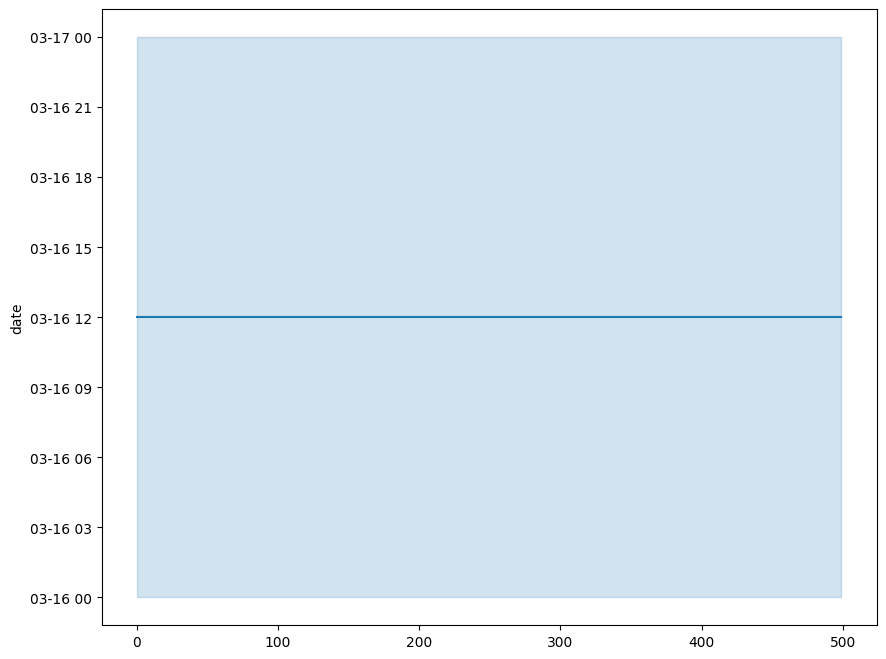

In [14]:
plt.figure(figsize = (10 ,8))
sns.lineplot(df['date'])

## Drop 
because of no veriance in the date column we can drop it

In [15]:
df.drop('date' , axis=1 , inplace=True)

In [16]:
df.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10


In [17]:
# check the null valuse in the data
df.isnull().sum()

coin          0
symbol        0
price         0
1h            7
24h           7
7d            8
24h_volume    7
mkt_cap       0
dtype: int64

## null values are present in the data

*1h , 24h , 24h_volume has 7 null values
*7d has 8 null values

In [18]:
# seprate the numerical and categoical columns

num_col = [num for num in df.columns if df[num].dtype !='str' ]
cat_col = [cat for cat in df.columns if df[cat].dtype == 'str']

In [19]:
num_col

['price', '1h', '24h', '7d', '24h_volume', 'mkt_cap']

In [20]:
cat_col

['coin', 'symbol']

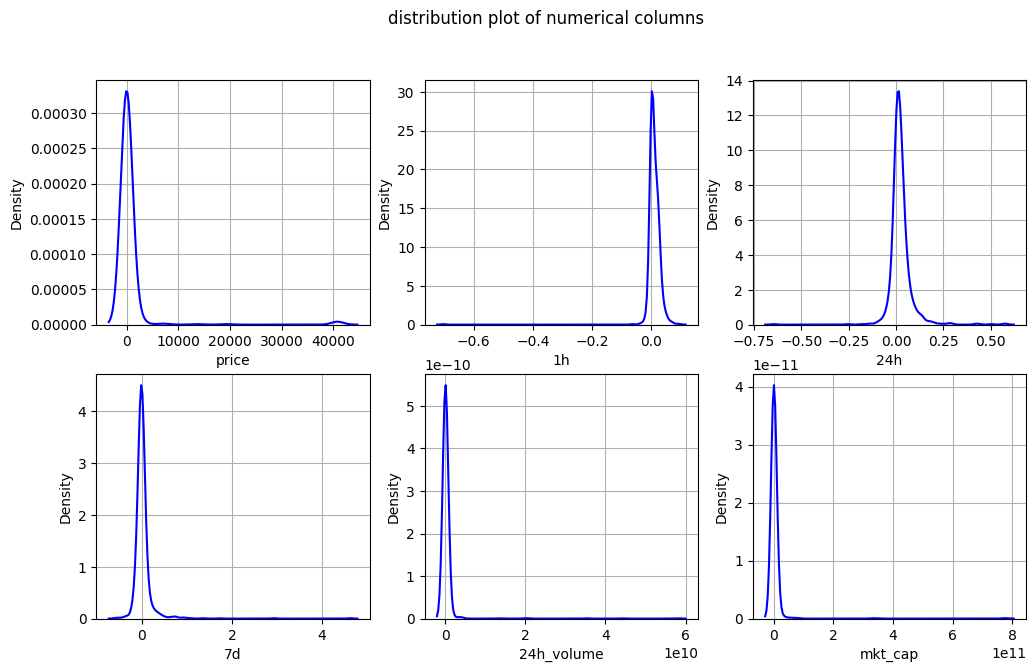

In [21]:
# kde plot of numerical columns

plt.figure(figsize=(12 , 7))
plt.suptitle('distribution plot of numerical columns')

for i in range(0 , len(num_col)):
    plt.subplot(2 , 3 , i+1)
    sns.kdeplot(df[num_col[i]] , color='b')
    plt.xlabel(num_col[i])
    plt.grid()
plt.show()

we can see the distribution of price , 7d , 24h_volume , mkt_cap are right squwed 
while 1h is left 

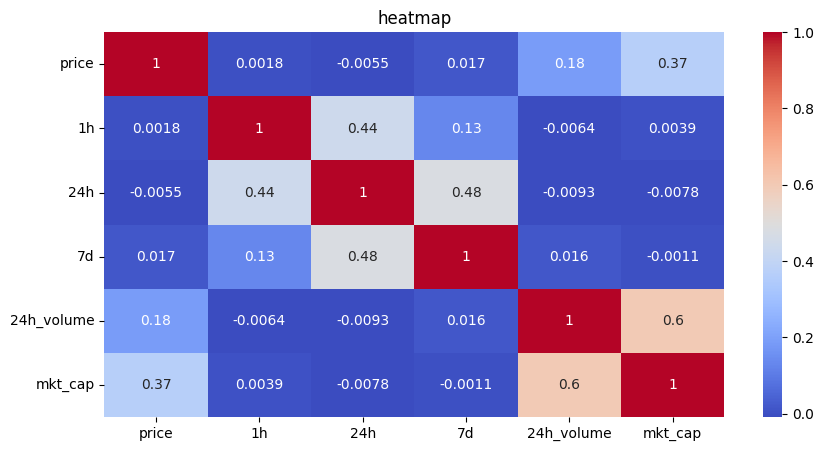

In [22]:
# coreelation plot of feture

plt.figure(figsize=(10 , 5))
sns.heatmap(df.corr(numeric_only=True) , cmap='coolwarm' , annot=True)
plt.title('heatmap' , fontsize=12)
plt.show()

## Relation - 

in the mkt_cap and 24h , 24h_volumne and 24h are negatively correlated


In [23]:
df.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10


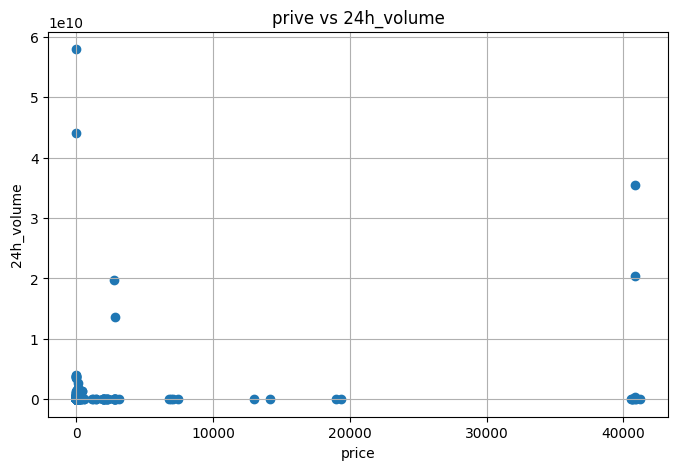

In [24]:
# relation b/w 24h_volume and price

plt.figure(figsize=(8 ,5))
plt.scatter(x = df['price'] , y = df['24h_volume'])
plt.title('prive vs 24h_volume')
plt.xlabel('price')
plt.ylabel('24h_volume')
plt.grid()
plt.show()

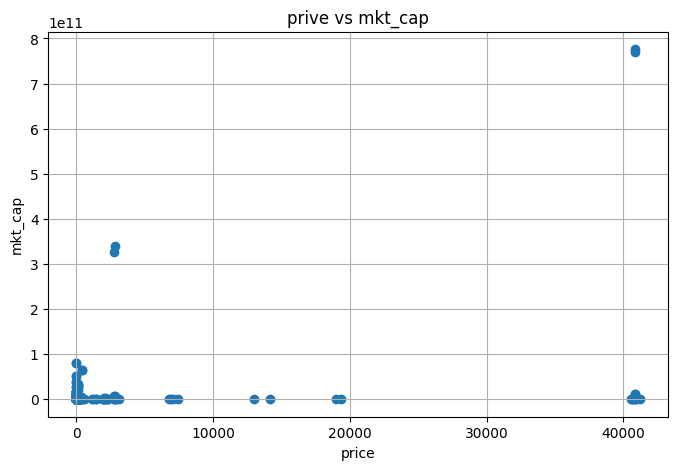

In [25]:
plt.figure(figsize=(8 ,5))
plt.scatter(x = df['price'] , y = df['mkt_cap'])
plt.title('prive vs mkt_cap')
plt.xlabel('price')
plt.ylabel('mkt_cap')
plt.grid()
plt.show()

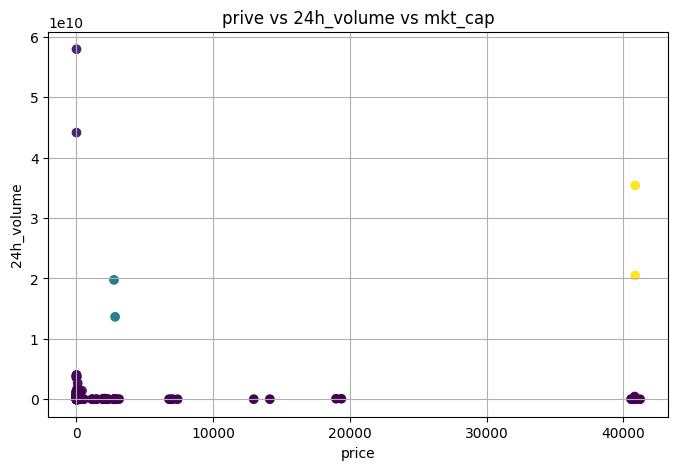

In [26]:
plt.figure(figsize=(8 ,5))
plt.scatter(x = df['price'] , y = df['24h_volume'] , c = df['mkt_cap'])
plt.title('prive vs 24h_volume vs mkt_cap')
plt.xlabel('price')
plt.ylabel('24h_volume')
plt.grid()
plt.show()

prive vs 24h_volume vs mkt_cap shown when the price will increse the market cap will also 

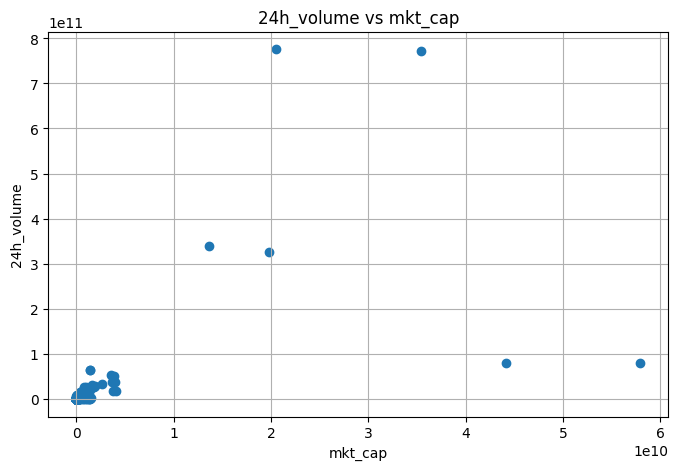

In [27]:
plt.figure(figsize=(8 ,5))
plt.scatter(x=df['24h_volume'] , y = df['mkt_cap'])
plt.title('24h_volume vs mkt_cap')
plt.xlabel('mkt_cap')
plt.ylabel('24h_volume')
plt.grid()
plt.show()

## Top 5 coins

In [28]:
# by price

cp = df[['coin' , 'price']].sort_values(by='price' , ascending=False).head()
cp

,coin,price
68,Huobi BTC,41217.27
69,Huobi BTC,40909.07
0,Bitcoin,40859.46
123,renBTC,40854.63
272,Interest Bearing Bitcoin,40853.81


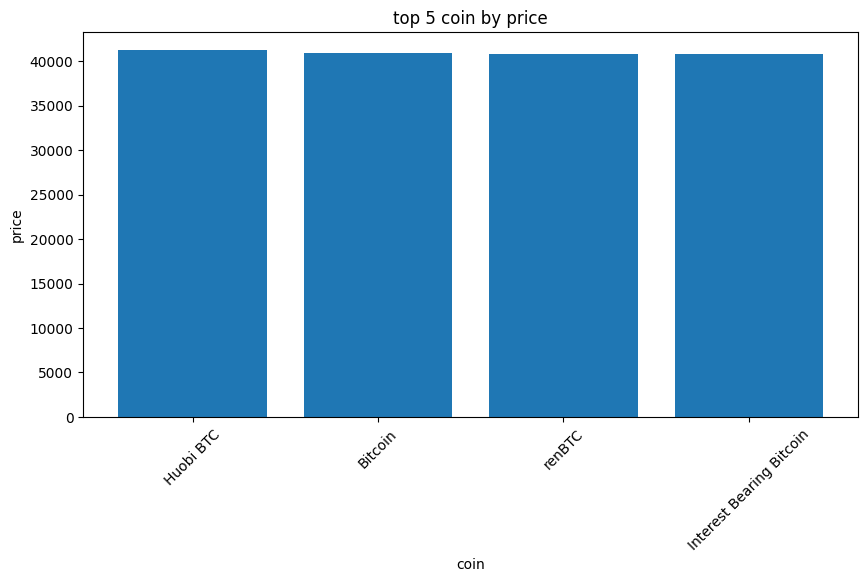

In [29]:
plt.figure(figsize=(10 ,5))
plt.bar(cp['coin'] , cp['price'] )
plt.title('top 5 coin by price')
plt.xlabel('coin')
plt.ylabel('price')
plt.xticks(rotation=45)
plt.show()

In [30]:
# by volume
cv = df[['coin' , '24h_volume']].sort_values(by='24h_volume' , ascending=False).head()
cv

,coin,24h_volume
2,Tether,5.793497e+10
2,Tether,4.413140e+10
0,Bitcoin,3.539076e+10
0,Bitcoin,2.047612e+10
1,Ethereum,1.974870e+10


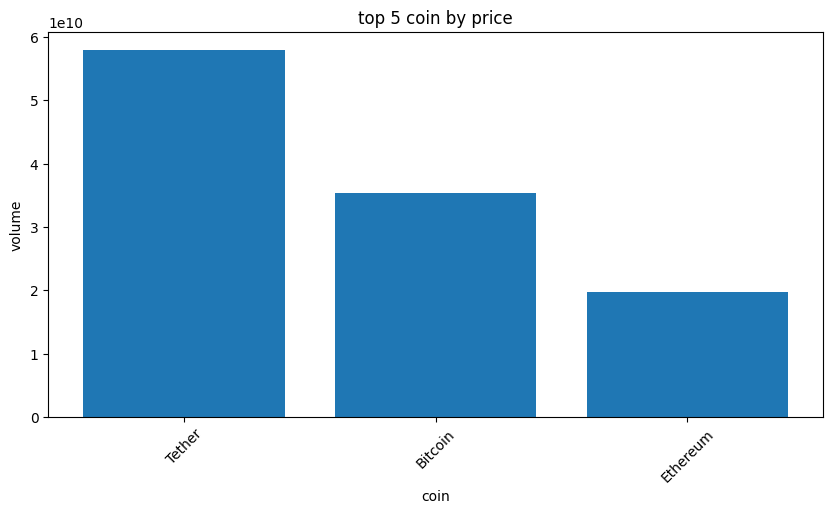

In [31]:
plt.figure(figsize=(10 ,5))
plt.bar(cv['coin'] , cv['24h_volume'])
plt.title('top 5 coin by price')
plt.xlabel('coin')
plt.ylabel('volume')
plt.xticks(rotation=45)
plt.show()

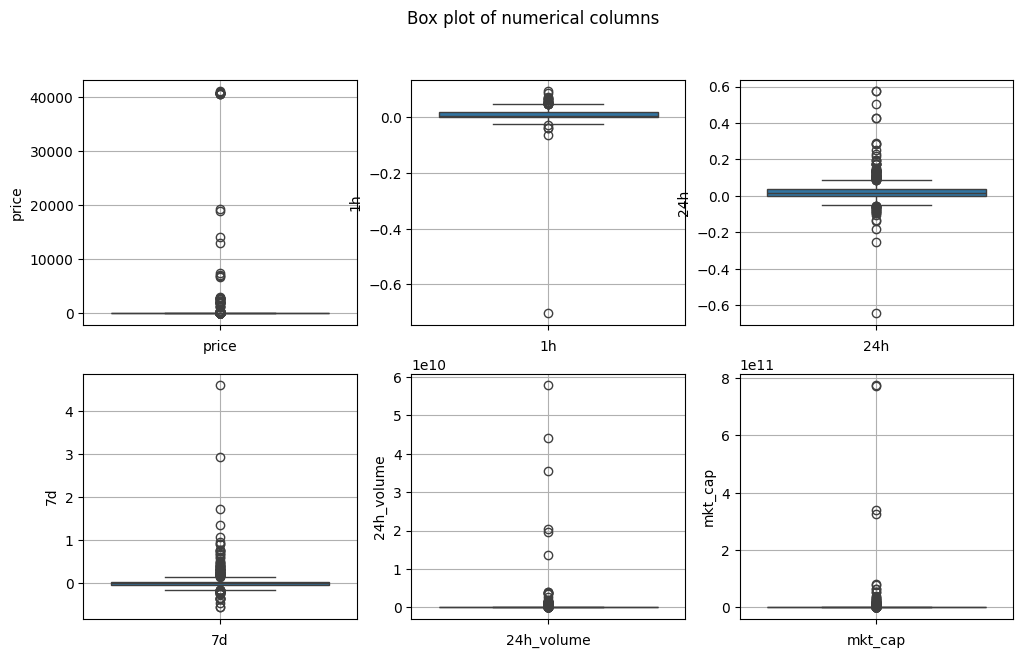

In [32]:
# check the outlier present or not

plt.figure(figsize=(12 , 7))
plt.suptitle('Box plot of numerical columns')

for i in range(0 , len(num_col)):
    plt.subplot(2 , 3 , i+1)
    sns.boxplot(df[num_col[i]])
    plt.xlabel(num_col[i])
    plt.grid()
plt.show()

we can clearly see the outlier are present in the data sets

In [33]:
df.isnull().sum()

coin          0
symbol        0
price         0
1h            7
24h           7
7d            8
24h_volume    7
mkt_cap       0
dtype: int64

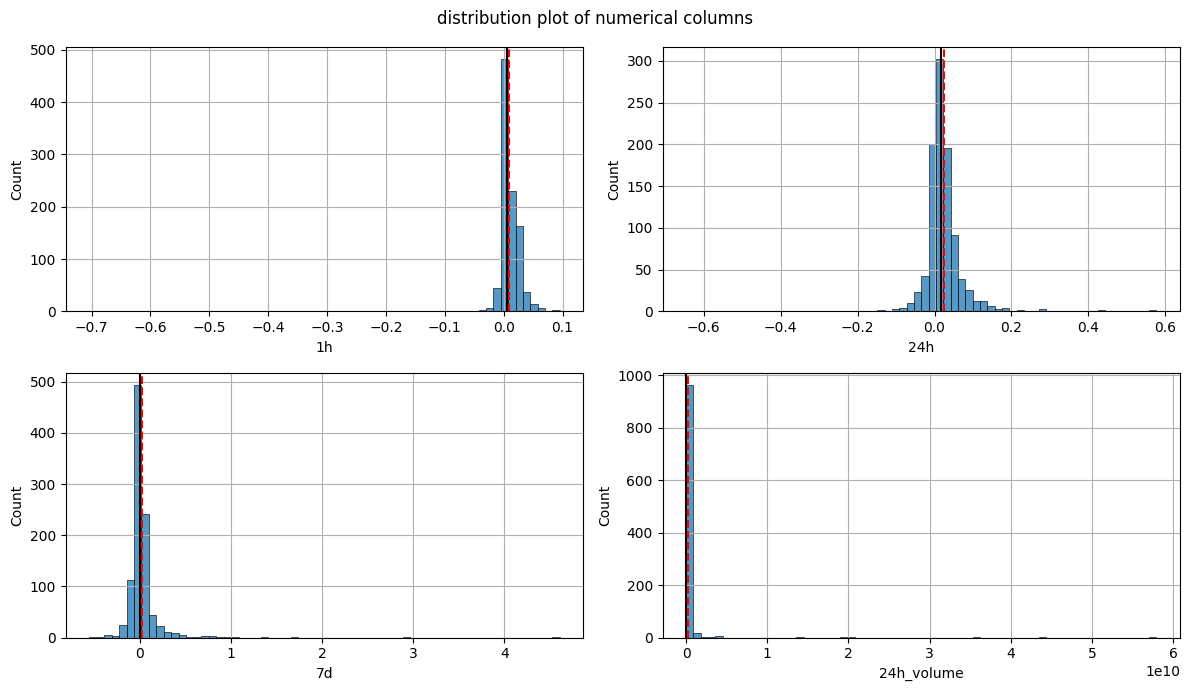

In [34]:
# find the method to fill null by hist plot

null_col = ['1h' , '24h' , '7d' , '24h_volume']

plt.figure(figsize=(12 , 7))
plt.suptitle('distribution plot of numerical columns')

for i in range(0 , len(null_col)):
    plt.subplot(2 , 2 , i+1)
    sns.histplot(df[null_col[i]])
    plt.axvline(df[null_col[i]].mean() , color='r' , linestyle='--')
    plt.axvline(df[null_col[i]].median() , color='black')
    plt.xlabel(null_col[i])
    plt.grid()
plt.tight_layout()
plt.show()

we can fill null value by both mean/median but first outlier handle

In [38]:
# handle the outlier

def outlier_handle(columns):

    for column in columns:
        
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)

        iqr = q3-q1

        upper_limit = q3 + iqr*1.5
        lower_limit = q1 - iqr*1.5
        df.loc[(df[column]>upper_limit), column]= upper_limit
        df.loc[(df[column]<lower_limit), column]= lower_limit

    plt.figure(figsize=(12 , 7))
    plt.suptitle('Box plot of numerical columns')

    for i in range(0 , len(columns)-1):
        plt.subplot(2 , 3 , i+1)
        sns.boxplot(df[columns[i+1]])
        plt.xlabel(columns[i+1])
        plt.grid()
    plt.show()
    

In [37]:
num_col

['price', '1h', '24h', '7d', '24h_volume', 'mkt_cap']

** Because price is target column can not apply normal outlier treatment

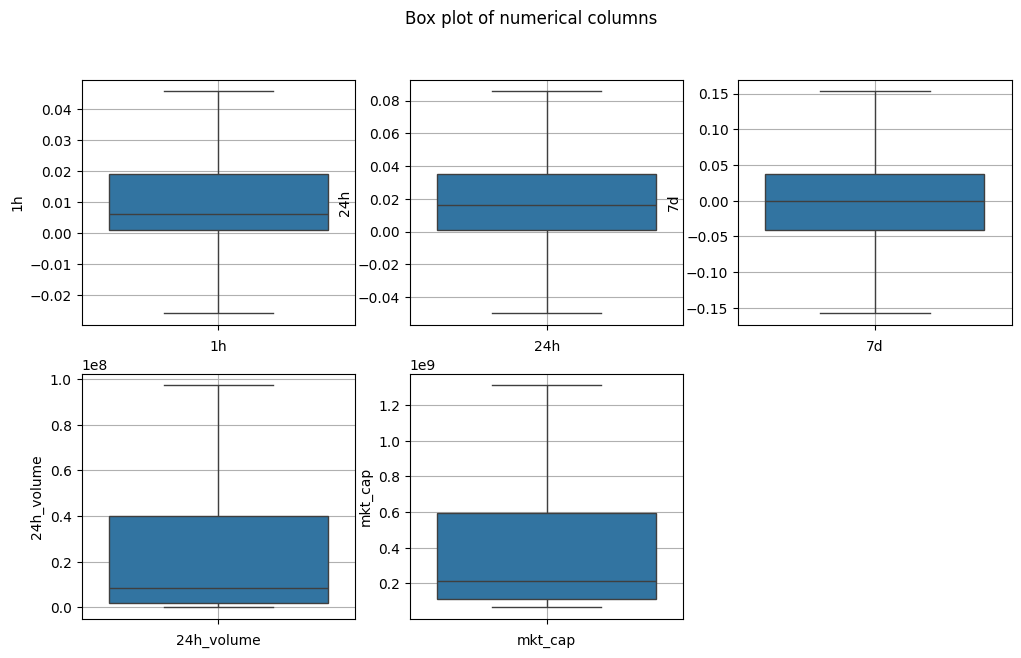

In [39]:
outlier_handle(num_col)

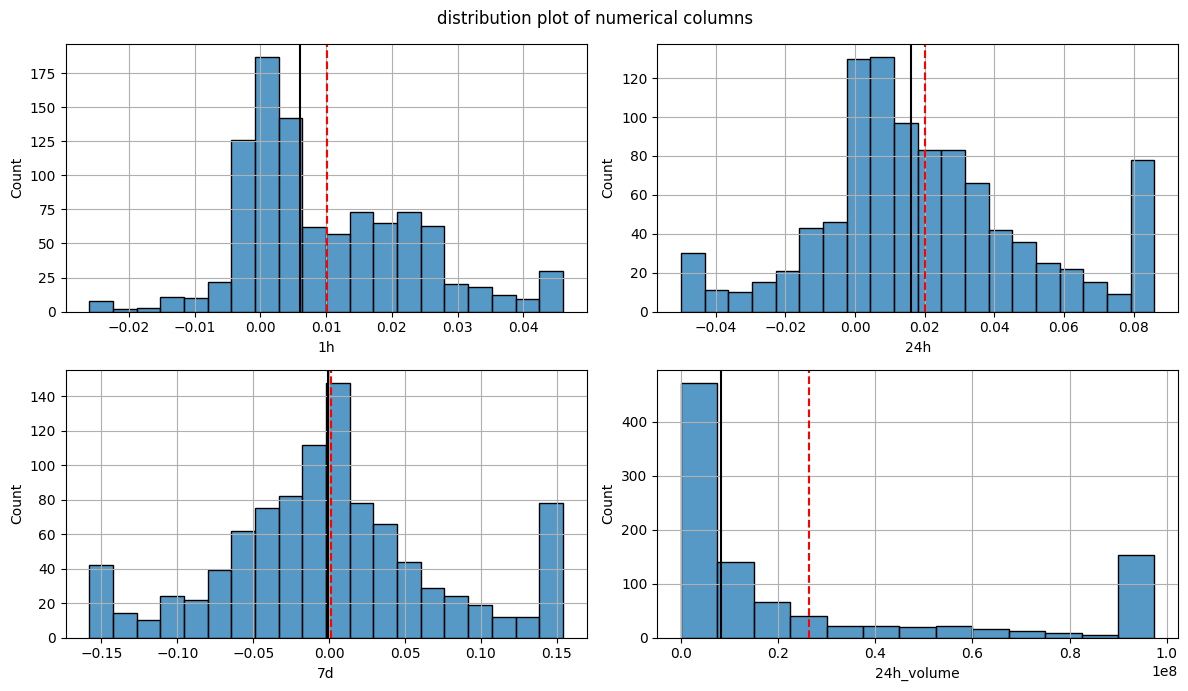

In [ ]:
# now check the null values treatment

null_col = ['1h' , '24h' , '7d' , '24h_volume']

plt.figure(figsize=(12 , 7))
plt.suptitle('distribution plot of numerical columns')

for i in range(0 , len(null_col)):
    plt.subplot(2 , 2 , i+1)
    sns.histplot(df[null_col[i]])
    plt.axvline(df[null_col[i]].mean() , color='r' , linestyle='--')
    plt.axvline(df[null_col[i]].median() , color='black')
    plt.xlabel(null_col[i])
    plt.grid()
plt.tight_layout()
plt.show()

we can clearly seen that some columns can be fill with either mean or median but some column like 1h and 24h_volumns are best to fill with mean

## Final Report

* In the dataset has outlier , missing values and correlation 
* missing valuse should be fill with mean
* Becuase of data column has no pattern we can drop it
* coin and symbol columns not give much infore mation to model we can also drop it
